In [13]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

sys.path.insert(0,'../')
from src.training.data_loader import build_streaming_dataset

In [14]:
import yaml
vocab_path='../data/processed/vocab.json'
with open(vocab_path,'r',encoding='utf8') as f:
    vocab=json.load(f)

with open('../config.yaml','r',encoding='utf8') as f:
    config=yaml.safe_load(f)

In [15]:
test_ds=build_streaming_dataset('../data/processed/test_data.jsonl',vocab_path=vocab_path,
                                max_length=config['TRAINING']['MAX_LENGTH'],
                                batch_size=config['TRAINING']['BATCH_SIZE'],
                                is_training=False,is_finite=True)

In [16]:
vocab_size=vocab['vocab_size']
model_params={
    'vocab_size':vocab_size,
    'embed_dim':config["MODEL"]["EMBEDDING_DIM"],
    'hidden_size': config["MODEL"]["HIDDEN_SIZE"],
    'num_layers': config["MODEL"]["NUM_LAYERS"],
    'dropout': config["MODEL"]["DROPOUT"]
}

In [17]:
from src.models.rnn_model import RNNModel
from src.models.lstm_model import LSTMModel

rnn_model=RNNModel(**model_params)
lstm_model=LSTMModel(**model_params)

rnn_checkpoints='../checkpoints/rnn_best.weights.h5'
lstm_checkpoints='../checkpoints/lstm_best.weights.h5'

dummy_input = tf.zeros((1, config["TRAINING"]["MAX_LENGTH"]), dtype=tf.int32)
rnn_model(dummy_input)
lstm_model(dummy_input)

rnn_model.load_weights(rnn_checkpoints)
lstm_model.load_weights(lstm_checkpoints)

rnn_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
lstm_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

# Confusion Matrix (Top 15 words)

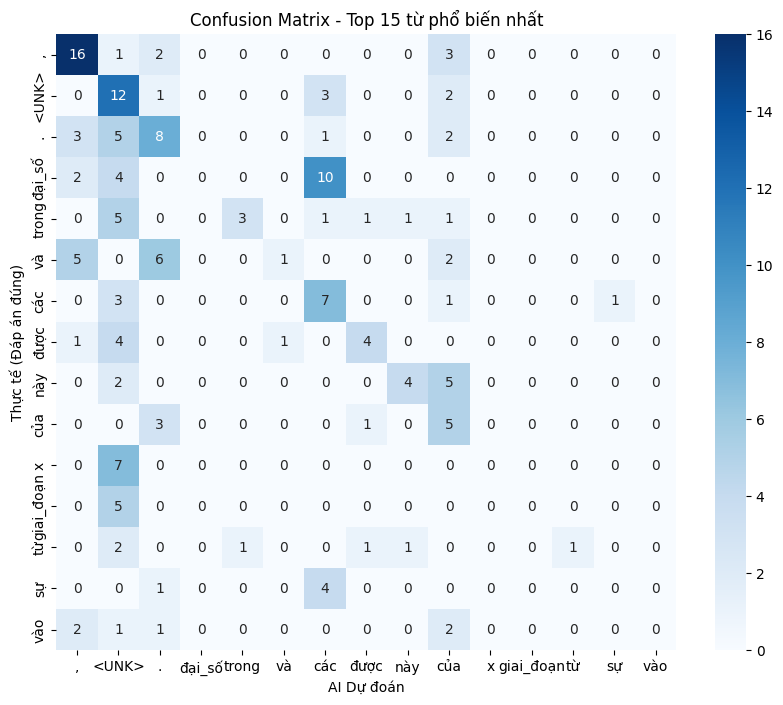

In [18]:
from sklearn.metrics import confusion_matrix
from collections import Counter

idx2word=vocab['idx2word']

def plot_top_words_confusion_matrix(model,dataset,idx2word,top_k=15):
    y_true_all=[]
    y_pre_all=[]
    
    for X_batch,y_batch in dataset.take(5):
        preds=model.predict(X_batch,verbose=0)
        y_pre_batch=np.argmax(preds,axis=-1)
        
        y_pre_all.extend(y_pre_batch)
        y_true_all.extend(y_batch.numpy())
    
    top_words_ids=[item[0] for item in Counter(y_true_all).most_common(top_k)]
    top_words_labels=[idx2word.get(str(i),"UNK") for i in top_words_ids]
    
    filtered_true, filtered_pred = [], []
    for t,p in zip(y_true_all,y_pre_all):
        if t in top_words_ids and p in top_words_ids:
            filtered_true.append(t)
            filtered_pred.append(p)
            
    cm = confusion_matrix(filtered_true, filtered_pred, labels=top_words_ids)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=top_words_labels, yticklabels=top_words_labels)
    plt.title('Confusion Matrix - Top 15 từ phổ biến nhất')
    plt.xlabel('AI Dự đoán')
    plt.ylabel('Thực tế (Đáp án đúng)')
    plt.show()

plot_top_words_confusion_matrix(lstm_model, test_ds, idx2word)

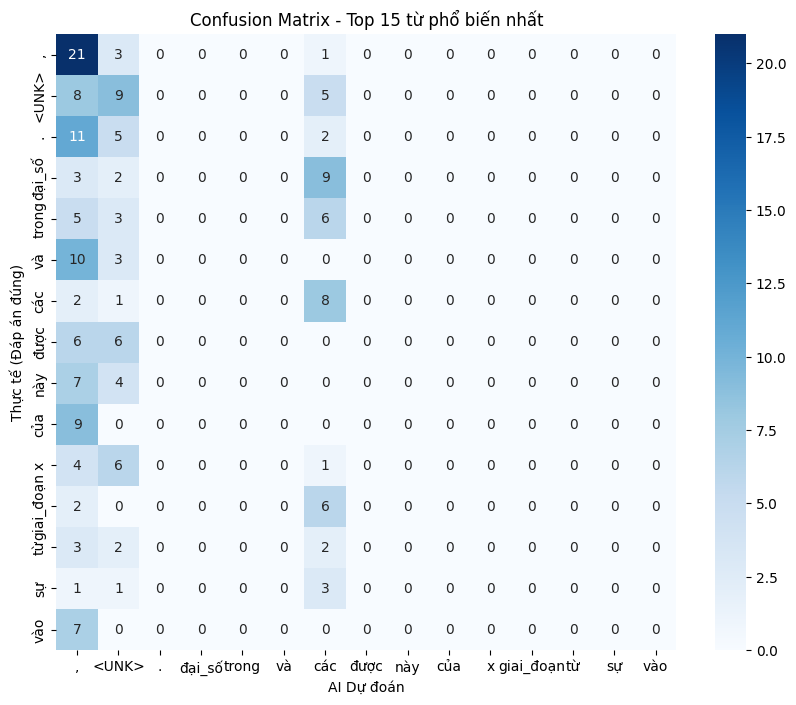

In [19]:
plot_top_words_confusion_matrix(rnn_model, test_ds, idx2word)

# Error analysis

In [20]:
def error_analysis(model,dataset,idx2word):
    loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True
                                                          ,reduction=tf.keras.losses.Reduction.NONE)
    errors=[]
    for X_batch,y_batch in dataset.take(10):
        preds=model.predict(X_batch,verbose=0)
        individual_losses=loss_fn(y_batch,preds)
        
        for i in range(len(y_batch)):
            X_text=" ".join([idx2word.get(str(idx),"<UNK>") for idx in X_batch[i].numpy() if idx>1])
            true_word=idx2word.get(str(y_batch[i].numpy()),"<UNK>")
            pred_word=idx2word.get(str(np.argmax(preds[i])),"<UNK>")
            
            errors.append({
                "context": X_text,
                "true_word": true_word,
                "pred_word": pred_word,
                "loss": individual_losses[i]
            })
    
    worst_predictions=sorted(errors,key=lambda x: x['loss'],reverse=True)[:5]
    
    print("Top 5 câu AI dự đoán tệ nhất (Loss cao nhất)")
    for idx, err in enumerate(worst_predictions):
        print(f"Hạng {idx+1} (Loss: {err['loss']:.2f})")
        print(f"Ngữ cảnh :  {err['context']}")
        print(f"Thực tế  : [{err['true_word']}]")
        print(f"AI đoán  : [{err['pred_word']}]")

In [21]:
error_analysis(rnn_model,test_ds,idx2word)

Top 5 câu AI dự đoán tệ nhất (Loss cao nhất)
Hạng 1 (Loss: 20.65)
Ngữ cảnh :  <BOS> trong báo_cáo thường_niên tình_trạng khí_hậu toàn_cầu công_bố hôm 23 3 , tổ_chức khí_tượng thế_giới
Thực tế  : [wmo]
AI đoán  : [,]
Hạng 2 (Loss: 20.57)
Ngữ cảnh :  chia thành ba phần xuất_hiện bởi_vì phương_trình bậc hai có hình_thức x 2 p x q 0 displaystyle x 2
Thực tế  : [px]
AI đoán  : [,]
Hạng 3 (Loss: 20.48)
Ngữ cảnh :  . thuật_ngữ từ đại_số xuất_phát từ một từ của tiếng ả_rập là , và từ này đến từ
Thực tế  : [chuyên_luận]
AI đoán  : [các]
Hạng 4 (Loss: 20.40)
Ngữ cảnh :  đầu thời_kỳ hiện_đại tất_cả các phương_trình được phân_loại vào 3 nhóm sau x 2 p x q displaystyle x 2
Thực tế  : [px]
AI đoán  : [,]
Hạng 5 (Loss: 20.38)
Ngữ cảnh :  nhóm sau x 2 p x q displaystyle x 2 px q x 2 p x q displaystyle x 2
Thực tế  : [px]
AI đoán  : [,]


In [22]:
error_analysis(lstm_model,test_ds,idx2word)

Top 5 câu AI dự đoán tệ nhất (Loss cao nhất)
Hạng 1 (Loss: 19.65)
Ngữ cảnh :  23 . translated by abe . the mathematical association of_america . , carl b . 1991 , a_history
Thực tế  : [of_mathematics]
AI đoán  : [<UNK>]
Hạng 2 (Loss: 19.59)
Ngữ cảnh :  antwerp , . b . 1940 , spanish word list , madison university press
Thực tế  : [ortega]
AI đoán  : [.]
Hạng 3 (Loss: 18.44)
Ngữ cảnh :  thế_kỷ 19 , đại_số bao_gồm một_cách đáng chú_ý lý_thuyết phương_trình . ví_dụ , định_lý gốc của đại_số thuộc về lý_thuyết
Thực tế  : [đẳng_thức]
AI đoán  : [của]
Hạng 4 (Loss: 18.22)
Ngữ cảnh :  phải sử_dụng sự hoàn_hảo của số không phải là lĩnh_vực đại_số . bài viết này sẽ nói về lý_thuyết
Thực tế  : [đẳng_thức]
AI đoán  : [của]
Hạng 5 (Loss: 18.00)
Ngữ cảnh :  annual report of_the board of of_the smithsonian institution ... for the year ending ngày 30 tháng 6 năm 1902
Thực tế  : [509]
AI đoán  : [.]
